# Introdução à POO com TypeScript para Redes Industriais

## Objetivo da monitoria
Entender os conceitos básicos de Programação Orientada a Objetos (POO) usando **TypeScript** e relacionar esses conceitos com situações comuns em redes industriais.

## Roteiro
- O que é POO
- Classe e objeto
- Atributos e métodos
- Encapsulamento, abstração, herança e polimorfismo
- Exemplos em TypeScript com contexto de redes industriais
- Exercícios para fixação


## 0.5 Por que typescript?

O TypeScript é uma linguagem com sintaxe semelhante à de Java, mas com configuração mais simples e maior facilidade de compreensão. Por isso, ele se torna uma boa opção para a introdução à programação, especialmente para estudantes com pouca experiência prévia.

## 1. O que é POO?

POO é uma forma de organizar programas usando **objetos** que representam elementos do mundo real.

Em redes industriais, isso é útil porque podemos representar:
- sensores
- CLPs
- IHMs
- switches industriais
- protocolos como Modbus TCP, PROFINET e EtherNet/IP

Em vez de trabalhar com variáveis soltas, agrupamos **dados** e **comportamentos** em estruturas mais organizadas.

## 2. Classe e objeto

Uma **classe** é um molde.

Um **objeto** é uma instância criada a partir desse molde.

Exemplo intuitivo:
- Classe: `DispositivoRede`
- Objetos: `clpLinha1`, `ihmPrincipal`

A classe define o que todo dispositivo deve ter.
O objeto representa um equipamento específico da rede.

In [ ]:
class DispositivoRede {
  nome: string;
  ip: string;
  protocolo: string;
  senha: string;

  constructor(nome: string, ip: string, protocolo: string) {
    this.nome = nome;
    this.ip = ip;
    this.protocolo = protocolo;
  }

  apresentar(): string {
    return `Dispositivo: ${this.nome} | IP: ${this.ip} | Protocolo: ${this.protocolo}`;
  }
}

const clpLinha1 = new DispositivoRede("CLP Linha 1", "192.168.0.10", "Modbus TCP");
const ihmPrincipal = new DispositivoRede("IHM Principal", "192.168.0.20", "PROFINET");

console.log(clpLinha1.apresentar());
console.log(ihmPrincipal.apresentar());


### Leitura do exemplo
- `nome`, `ip` e `protocolo` são **atributos**
- `apresentar()` é um **método**
- `clpLinha1` e `ihmPrincipal` são **objetos**

Em TypeScript, também declaramos os **tipos** dos atributos e dos retornos dos métodos. Isso ajuda na organização e na detecção de erros.

## 3. Os quatro pilares da POO

### 3.1 Encapsulamento
É a ideia de proteger e organizar os dados dentro do objeto.

Exemplo: um dispositivo pode controlar como seu estado é alterado, evitando mudanças incorretas.

### 3.2 Abstração
É mostrar apenas o que importa e esconder detalhes desnecessários.

Exemplo: para o usuário, interessa saber se o dispositivo está conectado, não necessariamente todos os passos internos da comunicação.

### 3.3 Herança
Permite criar novas classes a partir de uma classe base.

Exemplo: `SensorTemperatura` e `SensorPressao` podem herdar de uma classe `Sensor`.

### 3.4 Polimorfismo
Permite que objetos diferentes respondam ao mesmo método de formas diferentes.

Exemplo: vários protocolos podem ter um método `conectar()`, mas cada um implementa a conexão do seu jeito.

In [ ]:
abstract class Sensor {
  nome: string;
  unidade: string;

  constructor(nome: string, unidade: string) {
    this.nome = nome;
    this.unidade = unidade;
  }

  abstract lerValor(): string;
}

class SensorTemperatura extends Sensor {
  lerValor(): string {
    return `${this.nome}: 36.5 ${this.unidade}`;
  }
}

class SensorPressao extends Sensor {
  lerValor(): string {
    return `${this.nome}: 5.2 ${this.unidade}`;
  }
}

const sensores: Sensor[] = [
  new SensorTemperatura("Temperatura do Forno", "°C"),
  new SensorPressao("Pressão da Tubulação", "bar")
];

for (const sensor of sensores) {
  console.log(sensor.lerValor());
}


### Onde está cada pilar no exemplo?
- **Abstração**: a classe `Sensor` define a ideia geral de sensor
- **Herança**: `SensorTemperatura` e `SensorPressao` herdam de `Sensor`
- **Polimorfismo**: o método `lerValor()` existe em ambos, mas com comportamentos específicos
- **Encapsulamento**: cada objeto guarda seus próprios dados, como `nome` e `unidade`


## 4. Encapsulamento em TypeScript

TypeScript permite usar modificadores como `public`, `private` e `protected`.

- `public`: pode ser acessado de qualquer lugar
- `private`: só pode ser acessado dentro da própria classe
- `protected`: pode ser acessado na classe e nas subclasses

Isso é útil quando queremos proteger o estado interno de um equipamento.

In [ ]:
class CLP {
  public nome: string;
  private conectado: boolean;
  public conectadoPublico: boolean;

  constructor(nome: string) {
    this.nome = nome;
    this.conectado = false;
  }

  conectar(): void {
    this.conectado = true;
  }

  obterStatus(): string {
    return this.conectado ? "Conectado" : "Desconectado";
  }
}

const clp = new CLP("CLP Misturador");
console.log(clp.obterStatus());
clp.conectar();
console.log(clp.obterStatus());
clp.co


No exemplo acima, o atributo `conectado` é `private`. Isso significa que ele não deve ser alterado diretamente fora da classe. Assim, o próprio objeto controla seu estado. Além disso, ele não é exposto como pode ser visto na imagem abaixo, ao contrário de `conectadoPublico`.
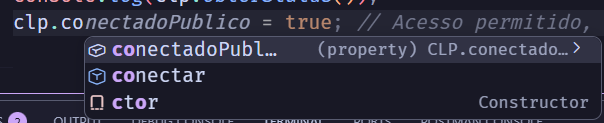

## 5. Aplicando POO em redes industriais

A principal vantagem de aprender orientação a objetos aqui não é apenas criar código do zero, mas conseguir **ler e entender repositórios reais**.

Muitos projetos, bibliotecas e exemplos usados no mercado seguem esse estilo de organização, com classes, métodos, abstrações e tipagem. Quando o aluno entende esses conceitos, ele passa a conseguir navegar melhor por códigos prontos, adaptar exemplos e estudar documentação com mais autonomia.

Um exemplo deste repositório está em `src/index.ts`. Nele aparece um cliente Modbus TCP usando `Socket`, criação de objeto com `new Modbus.client.TCP(socket)`, configuração de conexão e chamada de método para leitura de registradores. Mesmo sendo um exemplo simples, entender orientação a objetos ajuda a identificar rapidamente o papel de cada parte do código.

Ou seja: aprender POO também é aprender a **entender código de outras pessoas**, algo essencial quando se trabalha com bibliotecas, repositórios e exemplos de redes industriais.

In [ ]:
abstract class ProtocoloIndustrial {
  nome: string;

  constructor(nome: string) {
    this.nome = nome;
  }

  abstract conectar(): string;
}

class ModbusTCP extends ProtocoloIndustrial {
  conectar(): string {
    return `Conectando via ${this.nome} na porta 502`;
  }
}

class Profinet extends ProtocoloIndustrial {
  conectar(): string {
    return `Conectando via ${this.nome} em rede Ethernet industrial`;
  }
}

const protocolos: ProtocoloIndustrial[] = [
  new ModbusTCP("Modbus TCP"),
  new Profinet("PROFINET")
];

for (const protocolo of protocolos) {
  console.log(protocolo.conectar());
}


## 6. Boas práticas para quem está começando

- Dê nomes claros às classes e métodos
- Crie classes que representem entidades reais do problema
- Evite colocar tudo em uma única classe
- Use herança apenas quando realmente existir relação de especialização
- Prefira clareza antes de tentar deixar o código sofisticado
- Aproveite a tipagem do TypeScript para descrever bem os dados


## 7. Exercícios para treinar (Rode em example.ts)

1. Crie uma classe `Atuador` com os atributos `nome`, `estado` e um método `acionar()`.
2. Crie uma classe `SwitchIndustrial` com atributos `ip`, `fabricante` e um método `status()`.
3. Crie uma classe abstrata `Protocolo` e duas subclasses: `EthernetIP` e `ModbusTCP`.
4. Faça um programa que crie uma lista de dispositivos da rede e mostre suas informações.
5. Explique com suas palavras onde aparece polimorfismo em um exemplo de protocolos industriais.

## 8. Resumo final

POO ajuda a organizar programas em torno de objetos que representam elementos reais.

Os conceitos centrais que precisam ficar claros são:
- classe
- objeto
- atributo
- método
- encapsulamento
- abstração
- herança
- polimorfismo
